Seojin

# Notice

You can visualize plot only in mac. I tested vedo in Ubuntu, but It did not work.

# Vedo(Visualization of эD Objects)

Vedo is scientific tool for visualizing 3d objects

Official site: https://vedo.embl.es  
Github: https://github.com/marcomusy/vedo/tree/master/examples/notebooks

# Mesh

For visualizing 3d Object, You should make mesh(vertexes) based on nifti image. For making vtk file, I used nii2mesh.

Github: https://github.com/neurolabusc/nii2mesh

ex) nii2mesh lt_hippo_fan.nii lt_hippo_fan_d.vtk

# Library

In [3]:
import nilearn.plotting
import nibabel as nb
import vedo
from matplotlib import colormaps, cm, colors
import matplotlib.pyplot as plt
import numpy as np
from os.path import join, expanduser

In [4]:
vedo.settings.default_backend='vtk'

# Custom function

custom function for converting coordinate system.


In [6]:
def LPSp_toRASp(xyz):
    """
    Convert LPS+ coordinate to RAS+ coordinate
    
    :param xyz: LPS+ coord(list)
    
    return xyz(list)
    """
    x = xyz[0]
    y = xyz[1]
    z = xyz[2]
    
    return -x, -y, z

def RASp_toLPSp(xyz):
    """
    Convert RAS+ coordinate to LPS+ coordinate
    
    :param xyz: RAS+ coord(list)
    
    return xyz(list)
    """
    x = xyz[0]
    y = xyz[1]
    z = xyz[2]
    
    return -x, -y, z

def reference2imageCoord(xyz, affine):
    """
    change reference coordinate to image coordinate
    reference coordinate can be scanner coordinate or MNI coordinate...
    
    :param xyz: anatomical coordinate(np.array)
    :param affine: affine matrix(np.array)
    
    return image coordinate(np.array)
    """
    
    result = np.matmul(np.linalg.inv(affine), [xyz[0], xyz[1], xyz[2], 1])[0:3]
    result = np.ceil(result).astype(int) # note: This is ad-hoc process - (np.ceil)
    return result

# Paths

In [88]:
dir_path = "D:/Github/labs/GP"

# lt_putamen_nii_path = f"{dir_path}/putamen_caudateNucleus_left_HO.nii"
# rt_putamen_nii_path = f"{dir_path}/putamen_caudateNucleus_right_HO.nii"

lt_striatum_vtk_path = join(dir_path, 'scripts/KJH/GP_vis/putamen_caudateNucleus_left_HO.vtk')
rt_striatum_vtk_path = join(dir_path, 'scripts/KJH/GP_vis/putamen_caudateNucleus_right_HO.vtk')

# lt_putamen_nii_path = f"{dir_path}/mask.TTatlas.lh.caudate+putamen.resampled.binary.nii"
# rt_putamen_nii_path = f"{dir_path}/mask.TTatlas.rh.caudate+putamen.resampled.binary.nii"

# lt_putamen_vtk_path = f"{dir_path}/nii2mesh_mask.TTatlas.lh.caudate+putamen.resampled.binary.vtk"
# rt_putamen_vtk_path = f"{dir_path}/nii2mesh_mask.TTatlas.rh.caudate+putamen.resampled.binary.vtk"

# lt_putamen_vtk_path = f"{dir_path}/mask.TTatlas.lh.caudate+putamen.resampled.binary.vtk"
# rt_putamen_vtk_path = f"{dir_path}/mask.TTatlas.rh.caudate+putamen.resampled.binary.vtk"

## https://rordenlab.github.io/nii2meshWeb/
## Isolevel: custom 0.4, Post-smoothing: 496
# lt_putamen_vtk_path = f"/Users/clmn/Downloads/nii2mesh_mask.TTatlas.lh.caudate+putamen.resampled.binary.vtk"
# rt_putamen_vtk_path = f"/Users/clmn/Downloads/nii2mesh_mask.TTatlas.rh.caudate+putamen.resampled.binary.vtk"

# os.system(f"nii2mesh {lt_putamen_nii_path} -i b {lt_putamen_vtk_path}")
# os.system(f"nii2mesh {rt_putamen_nii_path} -i b {rt_putamen_vtk_path}")

striatum_vtk_volume_paths = [
    lt_striatum_vtk_path,
    rt_striatum_vtk_path
]

In [113]:
# Stat map
# stat_file_path = f"{dir_path}/r03-01.DLPFC_cTBS.n17.nii"
# stat_file_path = f"{dir_path}/Zstat.r03-01.M1_cTBS.n17.nii"
# stat_file_path = f"{dir_path}/Coef.DLPFC_cTBS-GA.nii"
# stat_file_path = f"{dir_path}/Coef.DLPFC_20Hz-GA.nii"
stat_file_path = join(dir_path, 'results/Zstat.DLPFC_cTBS_r03-r01-GA_r03-r01.nii')
# stat_file_path = f"{dir_path}/mask.TTatlas.ant.caudate+putamen.resampled.binary.nii"
stat = nb.load(stat_file_path)
print("stat-map shape:", stat.shape)
print(stat.affine)

# t_stat_index = 1
# t_stats = stat.get_fdata()[:,:,:,0, t_stat_index] # Select t-stat
t_stats = stat.get_fdata()
t_stats.shape

stat-map shape: (77, 92, 77)
[[   2.5    -0.     -0.    -95.  ]
 [  -0.      2.5    -0.   -131.75]
 [   0.      0.      2.5   -77.  ]
 [   0.      0.      0.      1.  ]]


(77, 92, 77)

# Visualize configuration


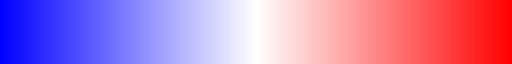

In [11]:
cmap = cm.bwr
cmap

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

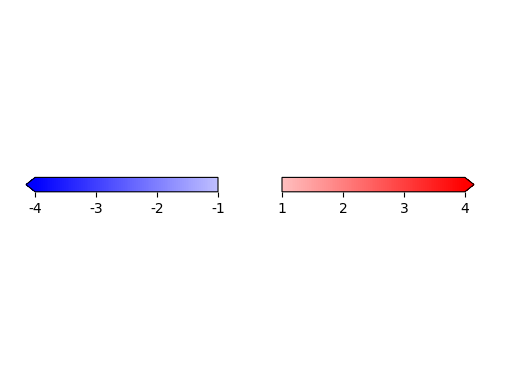

In [12]:
fig, ax = plt.subplots()

## 최대 최소 설정
vmax = 4.
vmin = -4.
thresh = 1
norm = colors.Normalize(vmin=vmin, vmax=vmax)

################
## upper cmap ##
################

### 컬러바 생성
array_cmap = cmap(range(cmap.N))[int(norm(thresh)*256):]
cmap_new = colors.ListedColormap(array_cmap)
colormapping = cm.ScalarMappable(
    norm=colors.Normalize(vmin=thresh, vmax=vmax),
    cmap=cmap_new
)
### 컬러바 삽입
# cax = fig.add_axes([0.05, .15, .015, .7])
cax = fig.add_axes([0.55, 0.5, .3, 0.03])
cbar = fig.colorbar(
    colormapping, extend='max',
    orientation='horizontal',
    format='%.0f',
    cax=cax)

################
## lower cmap ##
################

### 컬러바 생성
array_cmap = cmap(range(cmap.N))[:int(norm(-thresh)*256)]
cmap_new = colors.ListedColormap(array_cmap)
colormapping = cm.ScalarMappable(
    norm=colors.Normalize(vmin=vmin, vmax=-thresh),
    cmap=cmap_new
)
### 컬러바 삽입
# cax = fig.add_axes([0.0, 0.15, .03, 0.3])
cax = fig.add_axes([0.15, 0.5, .3, 0.03])
cbar = fig.colorbar(
    colormapping, extend='min',
    orientation='horizontal',
    format='%.0f',
    cax=cax
)
ax.axis('off')

# Load Data

In [115]:
# Load Vertex files - (Before skipping next part, you need to identify coordinate about data. 
# In my case, they are RAS+ coordinate
# target_vtk_volumes - volume for visualizing stat
striatum_vtk_volumes = [vedo.load(vtk_path) for vtk_path in striatum_vtk_volume_paths]
# Merge target volumes
striatum_vtk_volume = vedo.merge(striatum_vtk_volumes)

In [117]:
target = lt_striatum_vtk_path
# target = rt_striatum_vtk_path
target_volume = vedo.load(target)

# target_volume = striatum_vtk_volume

(array([4.03392901e-04, 2.00229567e-03, 7.86982878e-03, 2.10296054e-02,
        4.17108260e-02, 5.44103679e-02, 8.38237613e-01, 2.29512225e-02,
        8.45474848e-03, 2.36351568e-03, 5.66583666e-04]),
 array([-6., -5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.]),
 <BarContainer object of 11 artists>)

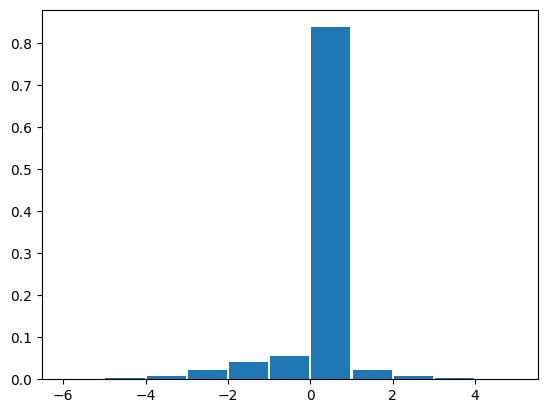

In [119]:
fig, ax = plt.subplots()
ax.hist(t_stats.flatten(), bins=np.arange(-6,6,1), align='mid', density=True, rwidth=0.95)

In [121]:
t_stats[(t_stats>-1.)&(t_stats<1)] = 0

# Merge target volumes

In [123]:
target_stats = []
for i, vertex in enumerate(target_volume.points()):
    RASp_coord = vertex
    image_coord = reference2imageCoord(RASp_coord, affine = stat.affine).astype(int)

    target_stats.append(t_stats[image_coord[0], image_coord[1], image_coord[2]])

In [125]:
# reverse y-axis
# target_vtk_volume = target_vtk_volume.clone(deep=False).mirror("y")

# Show


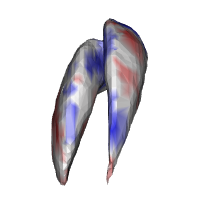

In [128]:
target_volume.cmap(cmap, target_stats, alpha=1.0, vmin=vmin, vmax=vmax)
target_volume.add_scalarbar(horizontal=True)

In [25]:
# Show
vedo.show(target_volume, axes=0, viewup='z', interactive=True, mode=0).close()
# vedo.show(target_vtk_volume, __doc__, viewup="z", axes=0).close()